In [48]:
import bagpipes as pipes
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from matplotlib.lines import Line2D

In [49]:
filt_splus_list = np.loadtxt("splus-filters/splus_filters.txt", dtype="str")
n_filters_splus = len(filt_splus_list)

band_names_splus = [str(p).split("/")[-1].replace(".dat", "") for p in filt_splus_list]
band_index_splus = {name: j for j, name in enumerate(band_names_splus)}

# Defina a grade de idades e metalicidades
ages = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 8.5, 12.0]) 
metallicities = np.array([0.0059, 0.029, 0.24, 0.47, 1.0, 1.76, 3.53]) 

# Gerar espectros livres de poeira para cada combinação
model_grid = []
for age in ages:
    for z in metallicities:
        burst = {}
        burst["massformed"] = 1.0 # Em log
        burst["metallicity"] = z # Em Z_sun
        burst["age"] = age

        dust = {}
        dust["type"] = "Calzetti"
        dust["Av"] = 0.0

        model_components = {}
        model_components["burst"] = burst
        model_components["dust"] = dust
        model_components["redshift"] = 0.0

        model = pipes.model_galaxy(model_components, filt_list=filt_splus_list)

        test_splus = np.full(len(filt_splus_list), 0.0)
        for j in range(len(filt_splus_list)):
            filt = np.loadtxt(filt_splus_list[j])
            central_wav = np.sqrt(simpson(filt[:, 1] * filt[:, 0], filt[:, 0]) / simpson(filt[:, 1] / filt[:, 0],  filt[:, 0]))
            test_splus[j] = -2.5 * np.log10(model.photometry[j]) - 5 * np.log10(central_wav) - 2.406

        model_grid.append(test_splus)

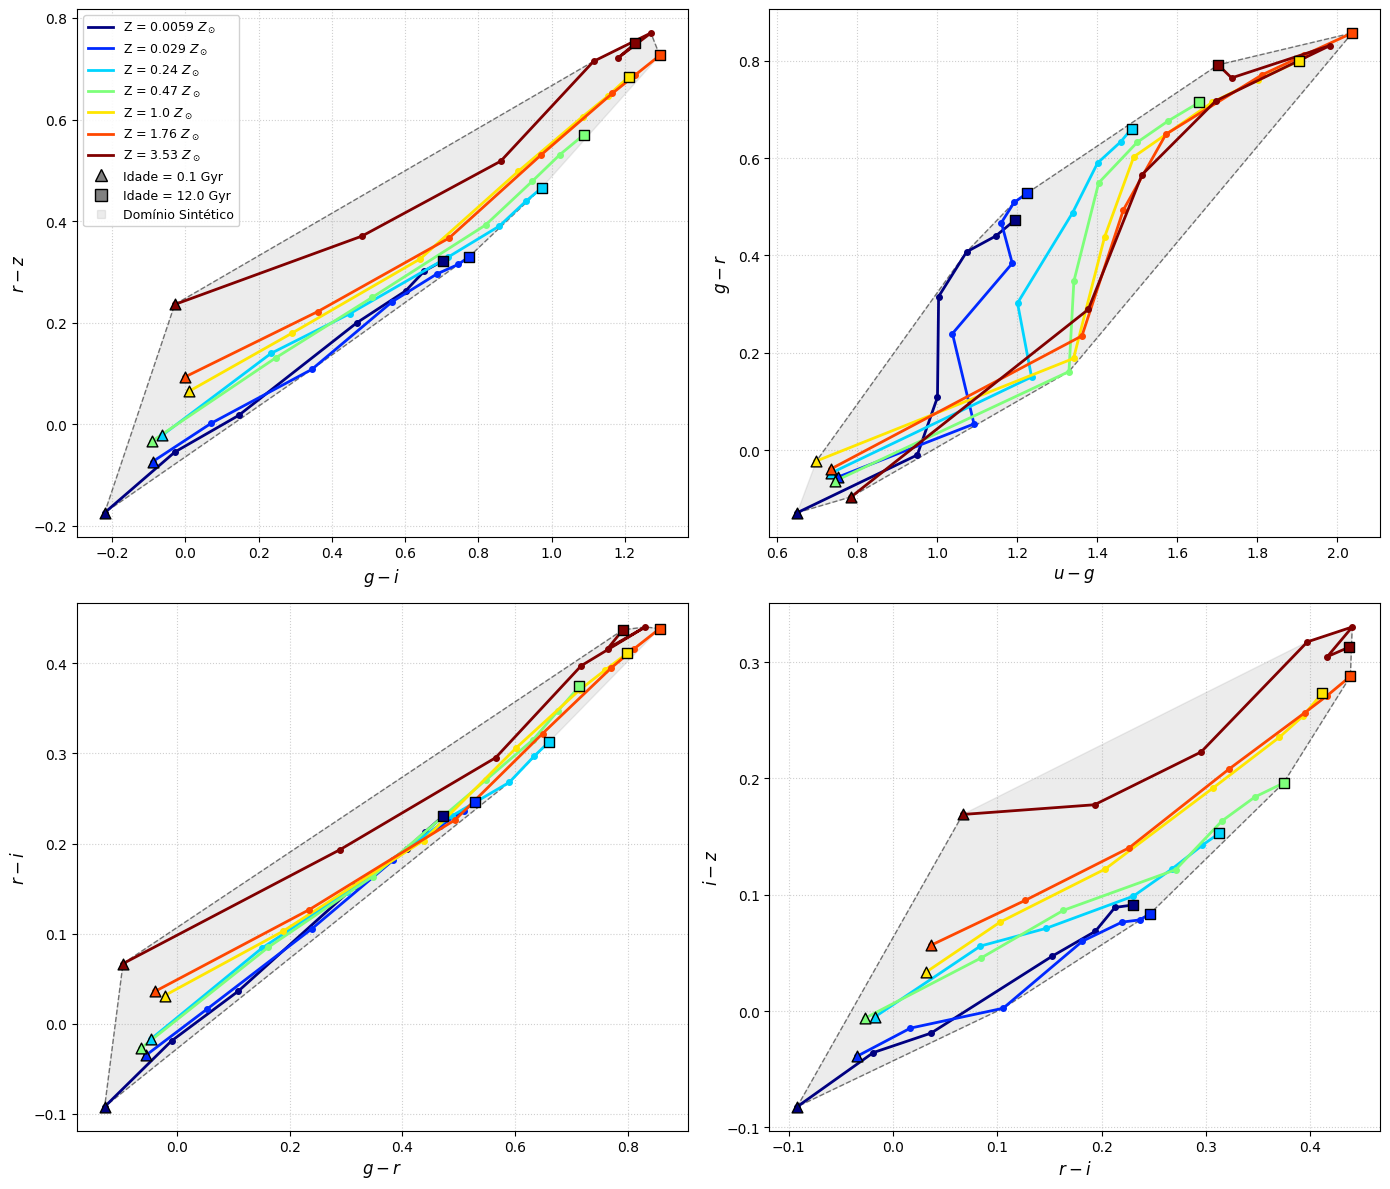

In [50]:
model_grid_np = np.array(model_grid)
model_grid_reshaped = model_grid_np.reshape((len(ages), len(metallicities), n_filters_splus))

plot_configs = [
    {'x': ('gSDSS', 'iSDSS'), 'y': ('rSDSS', 'zSDSS'), 'xlab': '$g - i$', 'ylab': '$r - z$'},
    {'x': ('uJAVA', 'gSDSS'),  'y': ('gSDSS', 'rSDSS'), 'xlab': '$u - g$', 'ylab': '$g - r$'},
    {'x': ('gSDSS', 'rSDSS'), 'y': ('rSDSS', 'iSDSS'), 'xlab': '$g - r$', 'ylab': '$r - i$'},
    {'x': ('rSDSS', 'iSDSS'), 'y': ('iSDSS', 'zSDSS'), 'xlab': '$r - i$', 'ylab': '$i - z$'}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

cmap = plt.get_cmap('jet')
colors = cmap(np.linspace(0, 1, len(metallicities)))

# Loop sobre cada subplot e sua configuração de cor
for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
    
    b1_x, b2_x = config['x']
    b1_y, b2_y = config['y']
    
    all_x, all_y = [], []
    
    # Plotando as Trilhas de evolução para cada metalicidade
    for z_idx, z in enumerate(metallicities):
        phot_z = model_grid_reshaped[:, z_idx, :]
        
        # Calcula as cores X e Y para esta combinação
        color_x = phot_z[:, band_index_splus[b1_x]] - phot_z[:, band_index_splus[b2_x]]
        color_y = phot_z[:, band_index_splus[b1_y]] - phot_z[:, band_index_splus[b2_y]]
        
        all_x.extend(color_x)
        all_y.extend(color_y)
        
        # Plota a linha sequencial por idade
        ax.plot(color_x, color_y, color=colors[z_idx], lw=2, marker='o', markersize=4, zorder=4)
        
        # Destaca populações jovens (triângulo) e velhas (quadrado)
        ax.scatter(color_x[0], color_y[0], color=colors[z_idx], marker='^', edgecolor='k', s=60, zorder=5) # Jovem
        ax.scatter(color_x[-1], color_y[-1], color=colors[z_idx], marker='s', edgecolor='k', s=50, zorder=5) # Velha

    # Cálculo e plotagem do Domínio Sintético
    points = np.column_stack((all_x, all_y))
    try:
        hull = ConvexHull(points)
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1], color='gray', alpha=0.15, zorder=2)
        ax.plot(points[hull.vertices, 0], points[hull.vertices, 1], 'k--', lw=1, alpha=0.5, zorder=3)
    except Exception as e:
        pass
    
    # Estilização de cada subplot
    ax.set_xlabel(config['xlab'], fontsize=12)
    ax.set_ylabel(config['ylab'], fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # legendas
    if ax_idx == 0:
        legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Z = {metallicities[i]} $Z_\\odot$') for i in range(len(metallicities))]
        legend_elements.append(Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='Idade = 0.1 Gyr'))
        legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='Idade = 12.0 Gyr'))
        legend_elements.append(Line2D([0], [0], marker='s', color='gray', alpha=0.15, lw=0, label='Domínio Sintético'))
        
        ax.legend(handles=legend_elements, loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

# Lendo dados do SPLUS já corrigidos da poeira da Via Láctea
splus_all_data = pd.read_csv("morphgal_corrected.csv")
filter_splus = (splus_all_data['u_auto'] < 21.3) & (splus_all_data['g_auto'] < 21.3) & (splus_all_data['r_auto'] < 21.3) & (splus_all_data['i_auto'] < 21.3) & (splus_all_data['z_auto'] < 21.3) \
               & (splus_all_data['J0378_auto'] < 21.3) & (splus_all_data['J0395_auto'] < 21.3) & (splus_all_data['J0410_auto'] < 21.3) & (splus_all_data['J0430_auto'] < 21.3) \
               & (splus_all_data['J0515_auto'] < 21.3) & (splus_all_data['J0660_auto'] < 21.3) & (splus_all_data['J0861_auto'] < 21.3) & (splus_all_data['zml'] < 0.1)

splus_data = splus_all_data[filter_splus].reset_index(drop=True)

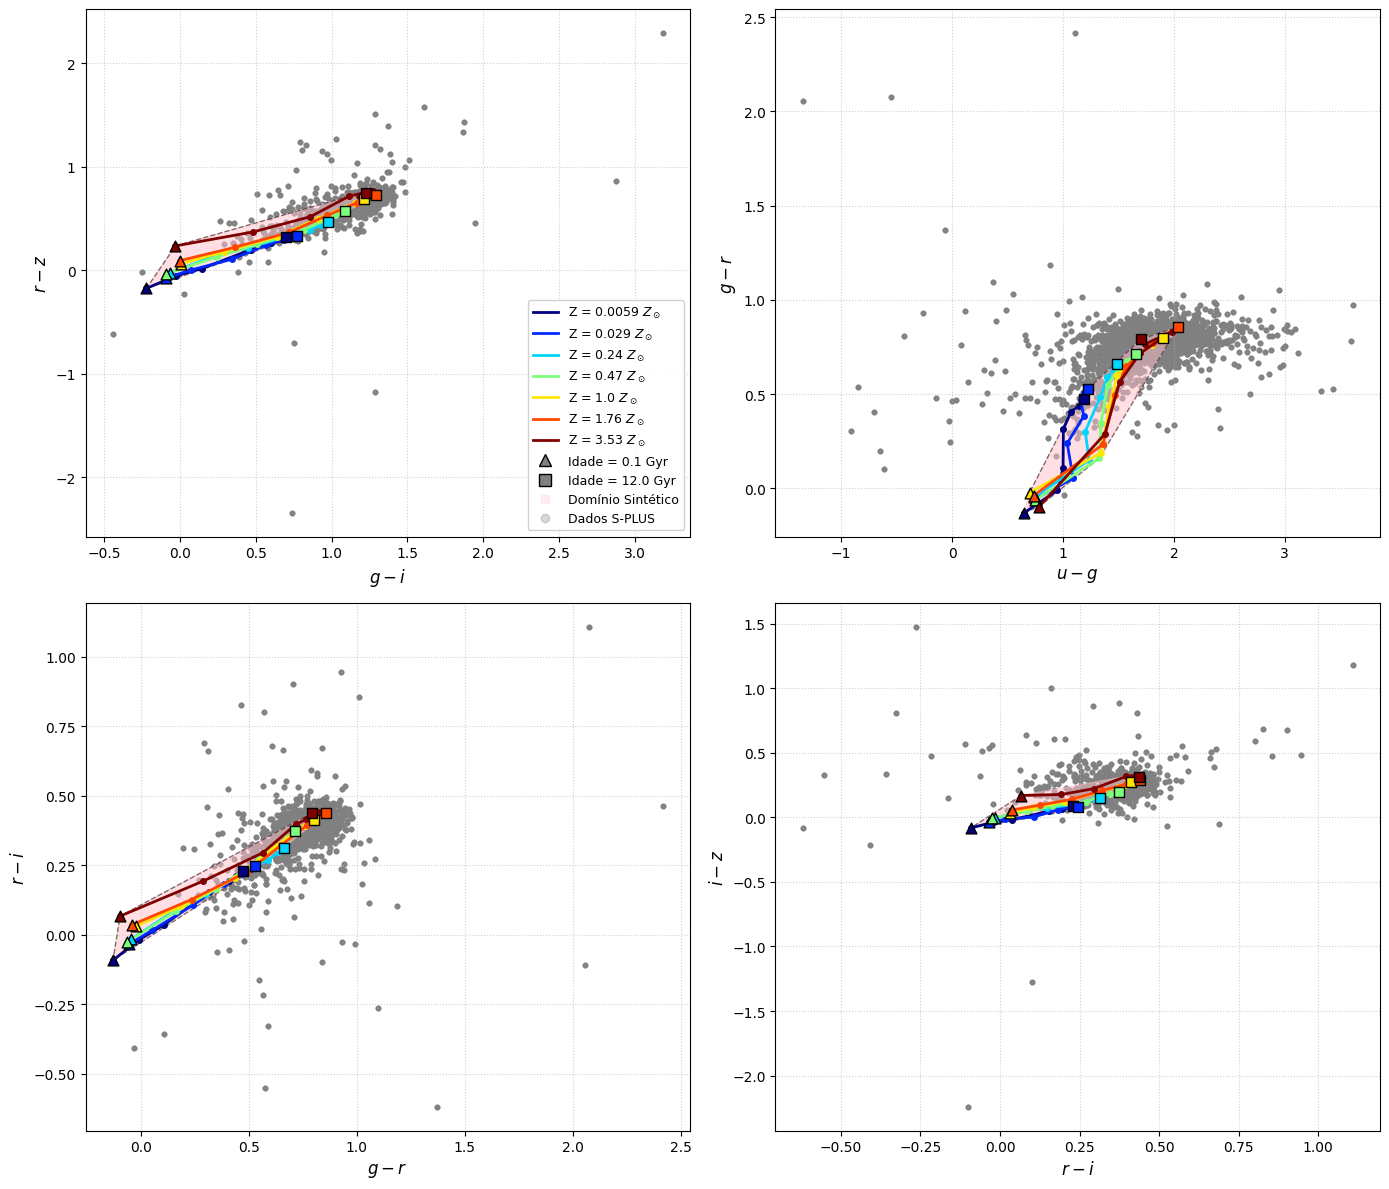

In [52]:
model_grid_np = np.array(model_grid)
model_grid_reshaped = model_grid_np.reshape((len(ages), len(metallicities), n_filters_splus))

plot_configs = [
    {'x': ('gSDSS', 'iSDSS'), 'y': ('rSDSS', 'zSDSS'), 'xlab': '$g - i$', 'ylab': '$r - z$'},
    {'x': ('uJAVA', 'gSDSS'),  'y': ('gSDSS', 'rSDSS'), 'xlab': '$u - g$', 'ylab': '$g - r$'},
    {'x': ('gSDSS', 'rSDSS'), 'y': ('rSDSS', 'iSDSS'), 'xlab': '$g - r$', 'ylab': '$r - i$'},
    {'x': ('rSDSS', 'iSDSS'), 'y': ('iSDSS', 'zSDSS'), 'xlab': '$r - i$', 'ylab': '$i - z$'}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors = cmap(np.linspace(0, 1, len(metallicities)))

# Loop sobre cada subplot e sua configuração de cor
for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
    
    b1_x, b2_x = config['x']
    b1_y, b2_y = config['y']
    
    all_x, all_y = [], []
    
    # Plotando as Trilhas de evolução para cada metalicidade
    for z_idx, z in enumerate(metallicities):
        phot_z = model_grid_reshaped[:, z_idx, :]
        
        # Calcula as cores X e Y para esta combinação
        color_x = phot_z[:, band_index_splus[b1_x]] - phot_z[:, band_index_splus[b2_x]]
        color_y = phot_z[:, band_index_splus[b1_y]] - phot_z[:, band_index_splus[b2_y]]

        splus_data_x = splus_data[b1_x[0] + '_auto'] - splus_data[b2_x[0] + '_auto']
        splus_data_y = splus_data[b1_y[0] + '_auto'] - splus_data[b2_y[0] + '_auto']
        
        all_x.extend(color_x)
        all_y.extend(color_y)
        
        # Plota a linha sequencial por idade
        ax.plot(color_x, color_y, color=colors[z_idx], lw=2, marker='o', markersize=4, zorder=4)
        
        # Destaca populações jovens (triângulo) e velhas (quadrado)
        ax.scatter(color_x[0], color_y[0], color=colors[z_idx], marker='^', edgecolor='k', s=60, zorder=5) # Jovem
        ax.scatter(color_x[-1], color_y[-1], color=colors[z_idx], marker='s', edgecolor='k', s=50, zorder=5) # Velha

        ax.scatter(splus_data_x, splus_data_y, color='gray', alpha=0.3, s=10, zorder=1) # Dados S-PLUS

    # Cálculo e plotagem do Domínio Sintético
    points = np.column_stack((all_x, all_y))
    try:
        hull = ConvexHull(points)
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1], color='pink', alpha=0.5, zorder=2)
        ax.plot(points[hull.vertices, 0], points[hull.vertices, 1], 'k--', lw=1, alpha=0.5, zorder=3)
    except Exception as e:
        pass
    
    # Estilização de cada subplot
    ax.set_xlabel(config['xlab'], fontsize=12)
    ax.set_ylabel(config['ylab'], fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # legendas
    if ax_idx == 0:
        legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Z = {metallicities[i]} $Z_\\odot$') for i in range(len(metallicities))]
        legend_elements.append(Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='Idade = 0.1 Gyr'))
        legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='Idade = 12.0 Gyr'))
        legend_elements.append(Line2D([0], [0], marker='s', color='pink', alpha=0.25, lw=0, label='Domínio Sintético'))
        legend_elements.append(Line2D([0], [0], marker='o', color='gray', alpha=0.30, lw=0, label='Dados S-PLUS'))
        
        ax.legend(handles=legend_elements, loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

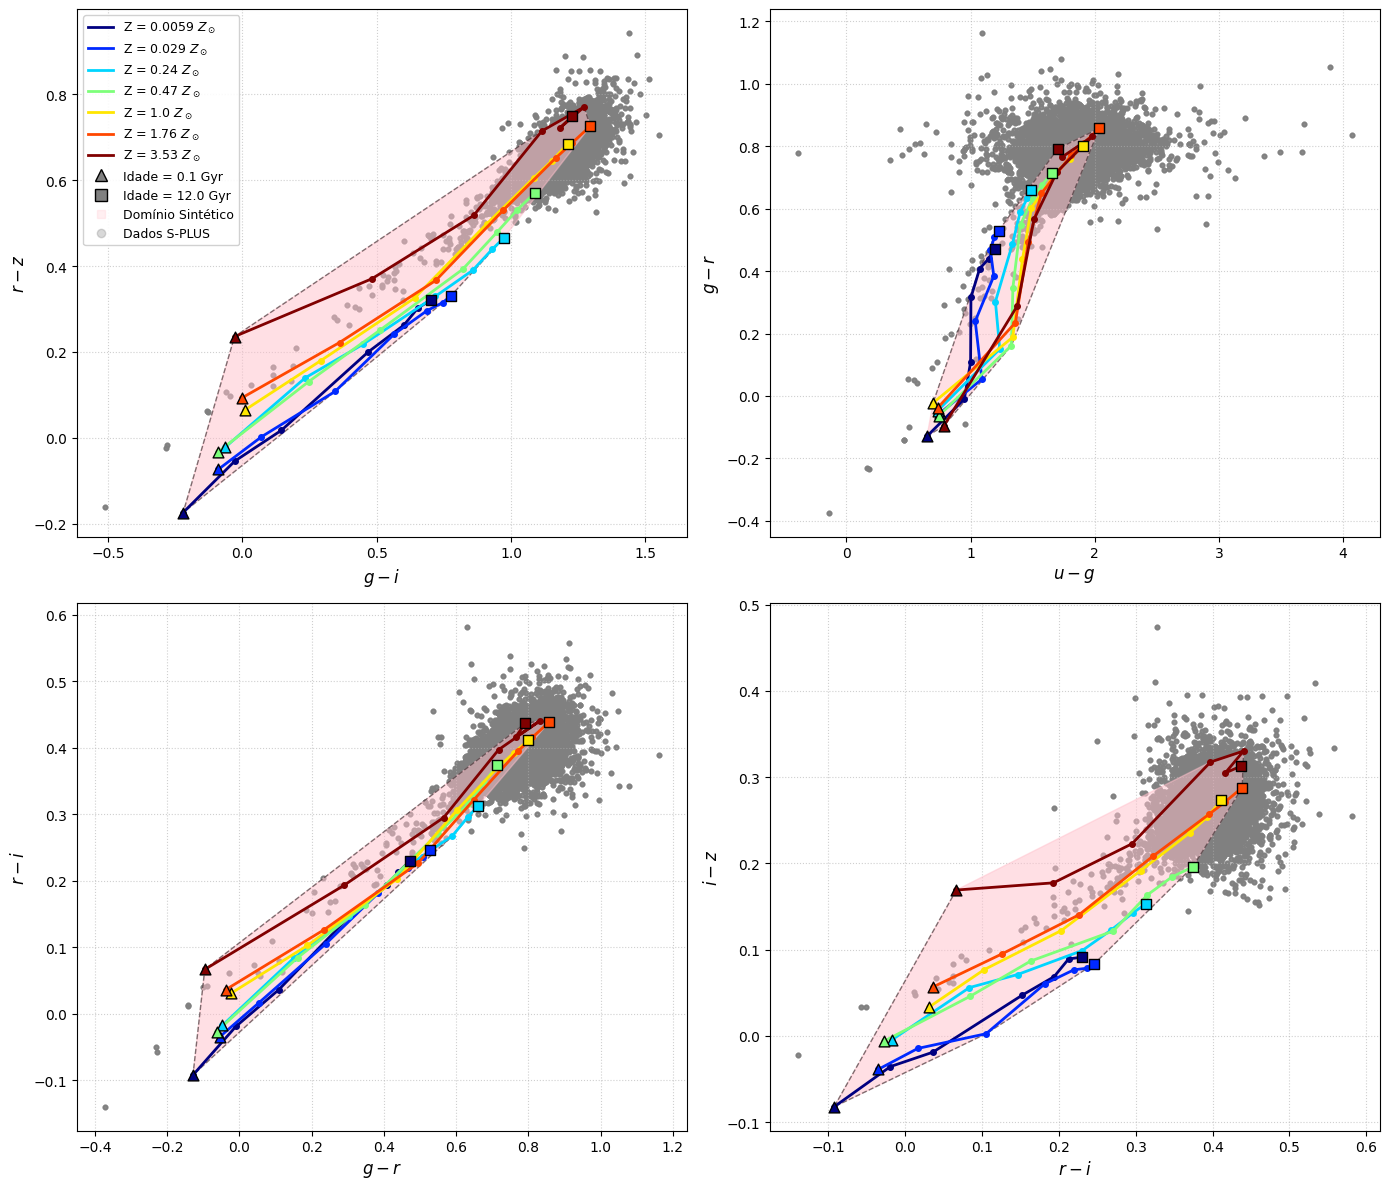

In [ ]:
realistic_spectra = pd.read_csv("Realistic_spectra.csv")

model_grid_np = np.array(model_grid)
model_grid_reshaped = model_grid_np.reshape((len(ages), len(metallicities), n_filters_splus))

plot_configs = [
    {'x': ('gSDSS', 'iSDSS'), 'y': ('rSDSS', 'zSDSS'), 'xlab': '$g - i$', 'ylab': '$r - z$'},
    {'x': ('uJAVA', 'gSDSS'),  'y': ('gSDSS', 'rSDSS'), 'xlab': '$u - g$', 'ylab': '$g - r$'},
    {'x': ('gSDSS', 'rSDSS'), 'y': ('rSDSS', 'iSDSS'), 'xlab': '$g - r$', 'ylab': '$r - i$'},
    {'x': ('rSDSS', 'iSDSS'), 'y': ('iSDSS', 'zSDSS'), 'xlab': '$r - i$', 'ylab': '$i - z$'}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors = cmap(np.linspace(0, 1, len(metallicities)))

# Loop sobre cada subplot e sua configuração de cor
for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
    
    b1_x, b2_x = config['x']
    b1_y, b2_y = config['y']
    
    all_x, all_y = [], []
    
    # Plotando as Trilhas de evolução para cada metalicidade
    for z_idx, z in enumerate(metallicities):
        phot_z = model_grid_reshaped[:, z_idx, :]
        
        # Calcula as cores X e Y para esta combinação
        color_x = phot_z[:, band_index_splus[b1_x]] - phot_z[:, band_index_splus[b2_x]]
        color_y = phot_z[:, band_index_splus[b1_y]] - phot_z[:, band_index_splus[b2_y]]

        realistic_data_x = realistic_spectra[b1_x] - realistic_spectra[b2_x]
        realistic_data_y = realistic_spectra[b1_y] - realistic_spectra[b2_y]
        
        all_x.extend(color_x)
        all_y.extend(color_y)
        
        # Plota a linha sequencial por idade
        ax.plot(color_x, color_y, color=colors[z_idx], lw=2, marker='o', markersize=4, zorder=4)
        
        # Destaca populações jovens (triângulo) e velhas (quadrado)
        ax.scatter(color_x[0], color_y[0], color=colors[z_idx], marker='^', edgecolor='k', s=60, zorder=5) # Jovem
        ax.scatter(color_x[-1], color_y[-1], color=colors[z_idx], marker='s', edgecolor='k', s=50, zorder=5) # Velha

        ax.scatter(realistic_data_x, realistic_data_y, color='gray', alpha=0.3, s=10, zorder=1) # Dados gerados

    # Cálculo e plotagem do Domínio Sintético
    points = np.column_stack((all_x, all_y))
    try:
        hull = ConvexHull(points)
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1], color='pink', alpha=0.5, zorder=2)
        ax.plot(points[hull.vertices, 0], points[hull.vertices, 1], 'k--', lw=1, alpha=0.5, zorder=3)
    except Exception as e:
        pass
    
    ax.set_xlabel(config['xlab'], fontsize=12)
    ax.set_ylabel(config['ylab'], fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # legendas
    if ax_idx == 0:
        legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Z = {metallicities[i]} $Z_\\odot$') for i in range(len(metallicities))]
        legend_elements.append(Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='Idade = 0.1 Gyr'))
        legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='Idade = 12.0 Gyr'))
        legend_elements.append(Line2D([0], [0], marker='s', color='pink', alpha=0.25, lw=0, label='Domínio Sintético'))
        legend_elements.append(Line2D([0], [0], marker='o', color='gray', alpha=0.30, lw=0, label='Dados Gerados'))
        
        ax.legend(handles=legend_elements, loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()